### Практичний крок 1 — Знаходимо шлях до файлів

In [1]:
import os

# Знаходимо всі файли датасету після Add Data на Kaggle
for root, dirs, files in os.walk("/kaggle/input"):
    for name in files:
        print(os.path.join(root, name))

# Очікуваний вивід:
# /kaggle/input/conll003-englishversion/train.txt
# /kaggle/input/conll003-englishversion/test.txt
# /kaggle/input/conll003-englishversion/valid.txt

# Створюємо директорію для збереження моделей
os.makedirs('/kaggle/working/models', exist_ok=True)

/kaggle/input/datasets/alaakhaled/conll003-englishversion/valid.txt
/kaggle/input/datasets/alaakhaled/conll003-englishversion/metadata
/kaggle/input/datasets/alaakhaled/conll003-englishversion/test.txt
/kaggle/input/datasets/alaakhaled/conll003-englishversion/train.txt


### Практичний крок 2 — Імпортуємо бібліотеки

In [2]:
import gc
import math
import random
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from torch.optim import Adam

# Сучасний tqdm — сумісний з Kaggle і Colab
# from tqdm import tqdm_notebook as tqdm  ← застарілий варіант (PyTorch < 1.9)
from tqdm.auto import tqdm               # сучасний варіант: auto обирає середовище

from sklearn.metrics import classification_report, f1_score

import warnings
warnings.filterwarnings('ignore')

### Практичний крок 3 — Визначаємо шляхи і device

In [3]:
# Шукаємо директорію з train.txt усередині /kaggle/input/
data_path = None
for root, dirs, files in os.walk("/kaggle/input"):
    if 'train.txt' in files:
        data_path = root + '/'
        break

# Якщо датасет не підключено — падаємо одразу з понятною помилкою,
# а не через 20 рядків усередині load_sentences
assert data_path is not None, "Датасет не знайдено! Add Data → conll003-englishversion"
print(f"data_path: {data_path}")

# device: використовуємо GPU якщо є (T4 на Kaggle), інакше CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Використовуємо: {device}")

data_path: /kaggle/input/datasets/alaakhaled/conll003-englishversion/
Використовуємо: cuda


### Практичний крок 4 — Завантажуємо дані (load_sentences)

In [4]:
def load_sentences(filepath):
    """Зчитує CoNLL2003-файл і повертає список речень у форматі
    [[(слово, тег), ...], [(слово, тег), ...], ...]"""
    final = []
    sentences = []
    with open(filepath, 'r') as f:
        for line in f.readlines():
            # Пропускаємо заголовок документа і порожні рядки (розділювачі речень)
            if (line == '-DOCSTART- -X- -X- O\n') or (line == '\n'):
                if len(sentences) > 0:
                    final.append(sentences)
                    sentences = []
            else:
                l = line.split(' ')
                # Беремо тільки слово (l[0]) і NER-мітку (l[3])
                sentences.append((l[0], l[3].strip('\n')))
    return final

# Завантажуємо три сплити
train_sents = load_sentences(data_path + 'train.txt')
test_sents  = load_sentences(data_path + 'test.txt')
val_sents   = load_sentences(data_path + 'valid.txt')

# Перевіряємо перші три речення
train_sents[:3]

[[('EU', 'B-ORG'),
  ('rejects', 'O'),
  ('German', 'B-MISC'),
  ('call', 'O'),
  ('to', 'O'),
  ('boycott', 'O'),
  ('British', 'B-MISC'),
  ('lamb', 'O'),
  ('.', 'O')],
 [('Peter', 'B-PER'), ('Blackburn', 'I-PER')],
 [('BRUSSELS', 'B-LOC'), ('1996-08-22', 'O')]]

#### Практичний крок 5 — Кодуємо мітки

In [5]:
# Список усіх NER-міток у датасеті
ner_labels = ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

# Словники для конвертації мітка ↔ індекс
id2label = {str(i): label for i, label in enumerate(ner_labels)}
label2id = {value: int(key) for key, value in id2label.items()}

def get_df(samples):
    """Перетворює список речень у словник {text: [...], label: [...]}
    де мітки закодовані числами"""
    df, label = [], []
    for lines in samples:
        cur_line, cur_label = list(zip(*lines))  # розпаковуємо кортежі
        df.append(list(cur_line))
        label.append([label2id[i] for i in cur_label])
    return {'text': df, 'label': label}

# Конвертуємо всі три сплити
train_df = get_df(train_sents)
test_df  = get_df(test_sents)
val_df   = get_df(val_sents)

### Практичний крок 6 — Будуємо словник

In [6]:
# Підраховуємо частоту кожного слова у тренувальному наборі
word_dict = defaultdict(int)
for line in train_df['text']:
    for word in line:
        word_dict[word] += 1

# Видаляємо слова, що зустрічаються менше 2 разів (занадто рідкісні)
lower_freq_word = [k for k, v in word_dict.items() if v < 2]
for word in lower_freq_word:
    del word_dict[word]

# Додаємо спеціальні токени
word_dict['<UNK>'] = -1   # для слів не зі словника (Out-Of-Vocabulary)
word_dict['<PAD>'] = -2   # для вирівнювання довжини речень у батчі

# Будуємо словник слово → числовий індекс
word2id = {}
for idx, word in enumerate(word_dict.keys()):
    word2id[word] = idx

print(f"Розмір словника: {len(word2id)}")

Розмір словника: 11984


### Практичний крок 7 — Dataset і Collate

In [7]:
def prepare_sequence(seq, to_ix):
    """Перетворює список слів у список числових індексів.
    Слова не зі словника замінюються на індекс <UNK>."""
    idxs = []
    for w in seq:
        if w in to_ix:
            idxs.append(to_ix[w])
        else:
            idxs.append(to_ix['<UNK>'])
    return idxs


class CoNLLDataset(Dataset):
    """PyTorch Dataset для CoNLL2003: повертає {input_ids, labels} для кожного речення."""
    def __init__(self, df):
        self.texts  = df['text']
        self.labels = df['label']

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        inputs = prepare_sequence(self.texts[item], word2id)  # слова → індекси
        label  = self.labels[item]
        return {'input_ids': inputs, 'labels': label}


class Collate:
    """Збирає речення різної довжини у батч однакової розмірності через padding."""
    def __init__(self, train):
        self.train = train   # True під час тренування (потрібні мітки), False при inference

    def __call__(self, batch):
        output = {}
        output["input_ids"] = [sample["input_ids"] for sample in batch]
        if self.train:
            output["labels"] = [sample["labels"] for sample in batch]

        # Знаходимо максимальну довжину речення в батчі
        batch_max = max(len(ids) for ids in output["input_ids"])

        # Додаємо padding до кожного речення до довжини batch_max
        output["input_ids"] = [
            s + (batch_max - len(s)) * [word2id['<PAD>']]
            for s in output["input_ids"]
        ]
        if self.train:
            # Мітки для паддінг-токенів = -100 → CrossEntropyLoss їх ігнорує
            output["labels"] = [
                s + (batch_max - len(s)) * [-100]
                for s in output["labels"]
            ]

        # Конвертуємо у torch.Tensor
        output["input_ids"] = torch.tensor(output["input_ids"], dtype=torch.long)
        if self.train:
            output["labels"] = torch.tensor(output["labels"], dtype=torch.long)

        return output

collate_fn = Collate(True)

### Практичний крок 8 — DataLoader

In [16]:
# Створюємо Dataset-об'єкти для кожного сплиту
train_dataset = CoNLLDataset(train_df)
val_dataset   = CoNLLDataset(val_df)
test_dataset  = CoNLLDataset(test_df)

# DataLoader: подає батчі моделі; collate_fn вирівнює довжини
train_loader = DataLoader(train_dataset,
                          batch_size=32,
                          shuffle=False,
                          collate_fn=collate_fn,
                          num_workers=0,       # ставимо 0, бо 2 спричиняли шумні AssertionError: can only test a child process між епохами
                          pin_memory=True,
                          drop_last=False)

val_loader = DataLoader(val_dataset,
                        batch_size=32,
                        shuffle=False,
                        collate_fn=collate_fn,
                        num_workers=0,
                        pin_memory=True,
                        drop_last=False)

test_loader = DataLoader(test_dataset,
                         batch_size=32,
                         shuffle=False,
                         collate_fn=collate_fn,
                         num_workers=0,
                         pin_memory=True,
                         drop_last=False)

### Практичний крок 9 — BiLSTMTagger

In [17]:
class BiLSTMTagger(nn.Module):
    """Bi-LSTM модель для NER.
    Архітектура: Embedding → 3-шарова Bi-LSTM → Linear(2*H → num_classes)"""

    def __init__(self, embedding_dim, hidden_dim, vocab_size, output_size, embeddings=None):
        super(BiLSTMTagger, self).__init__()

        # 1. Шар ембедингів: кожен індекс слова → вектор розміром embedding_dim
        if embeddings is None:
            # Навчаємо ембединги з нуля
            self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        else:
            # Завантажуємо претреновані (наприклад, GloVe)
            self.embeddings = nn.Embedding.from_pretrained(embeddings)

        # 2. Bi-LSTM: читає послідовність ембедингів у двох напрямках
        self.lstm = nn.LSTM(
            embedding_dim,        # розмір вхідного вектора
            hidden_dim,           # розмір прихованого стану одного LSTM
            bidirectional=True,   # запустити прямий і зворотний LSTM
            num_layers=3,         # три послідовні LSTM-шари (глибока модель)
            batch_first=True      # перший вимір = batch (зручно для нас)
        )

        # 3. Лінійний шар: 2*hidden_dim → кількість класів
        # 2* бо bidirectional об'єднує прямий і зворотний вихід конкатенацією
        self.fc = nn.Linear(2 * hidden_dim, output_size)

    def forward(self, batch_text):
        # batch_text: (B, T) — індекси слів
        embeddings = self.embeddings(batch_text)     # → (B, T, embedding_dim)

        lstm_output, _ = self.lstm(embeddings)       # → (B, T, 2*hidden_dim)

        logits = self.fc(lstm_output)                # → (B, T, num_classes)
        return logits

### Практичний крок 10 — Допоміжні функції

In [18]:
def remove_predictions_for_masked_items(predicted_labels, correct_labels):
    """Видаляє передбачення і мітки для PAD-токенів (мітки <= 0).
    Нас цікавить лише якість на реальних словах (мітки 1–8)."""
    predicted_labels_without_mask = []
    correct_labels_without_mask   = []

    for p, c in zip(predicted_labels, correct_labels):
        if c > 0:    # 0 = клас 'O' (є реальним), > 0 = NER-класи; -100 = PAD
            predicted_labels_without_mask.append(p)
            correct_labels_without_mask.append(c)

    return predicted_labels_without_mask, correct_labels_without_mask

### Практичний крок 11 — Функція тренування (train)

In [19]:
def train(model, train_loader, val_loader, batch_size, max_epochs, num_batches, patience, output_path):
    """Тренує модель з early stopping; зберігає найкращу модель за val macro F1."""

    # Функція втрат: CrossEntropy ігнорує індекс -100 (PAD-мітки)
    criterion = nn.CrossEntropyLoss(ignore_index=-100)
    optimizer = Adam(model.parameters())

    train_f_score_history = []
    dev_f_score_history   = []
    no_improvement = 0

    for epoch in range(max_epochs):
        total_loss = 0
        predictions, correct = [], []

        # ── Тренувальна фаза ──────────────────────────────────
        model.train()
        for batch in tqdm(train_loader, total=num_batches, desc=f"Epoch {epoch}"):
            cur_batch_size, text_length = batch['input_ids'].shape

            # Forward pass: (B, T, C)  →  розгорнути у (B*T, C) для CrossEntropy
            pred = model(batch['input_ids'].to(device)).view(cur_batch_size * text_length, NUM_CLASSES)
            gold = batch['labels'].to(device).view(cur_batch_size * text_length)

            loss = criterion(pred, gold)
            total_loss += loss.item()

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Збираємо передбачення для метрики
            _, pred_indices = torch.max(pred, 1)
            predicted_labels = list(pred_indices.cpu().numpy())
            correct_labels   = list(batch['labels'].view(cur_batch_size * text_length).numpy())

            predicted_labels, correct_labels = remove_predictions_for_masked_items(
                predicted_labels, correct_labels
            )
            predictions += predicted_labels
            correct     += correct_labels

        train_score = f1_score(correct, predictions, average="macro")
        train_f_score_history.append(train_score)
        print(f"Total training loss: {total_loss:.4f}")
        print(f"Training Macro F1:   {train_score:.4f}")

        # ── Валідаційна фаза ───────────────────────────────────
        total_loss = 0
        predictions, correct = [], []

        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                cur_batch_size, text_length = batch['input_ids'].shape

                pred = model(batch['input_ids'].to(device)).view(cur_batch_size * text_length, NUM_CLASSES)
                gold = batch['labels'].to(device).view(cur_batch_size * text_length)

                loss = criterion(pred, gold)
                total_loss += loss.item()

                _, pred_indices = torch.max(pred, 1)
                predicted_labels = list(pred_indices.cpu().numpy())
                correct_labels   = list(batch['labels'].view(cur_batch_size * text_length).numpy())

                predicted_labels, correct_labels = remove_predictions_for_masked_items(
                    predicted_labels, correct_labels
                )
                predictions += predicted_labels
                correct     += correct_labels

        dev_score = f1_score(correct, predictions, average="macro")
        print(f"Total validation loss: {total_loss:.4f}")
        print(f"Validation Macro F1:   {dev_score:.4f}")

        # ── Early stopping ─────────────────────────────────────
        if len(dev_f_score_history) > patience and dev_score < max(dev_f_score_history):
            no_improvement += 1
        elif len(dev_f_score_history) == 0 or dev_score > max(dev_f_score_history):
            print("Зберігаємо модель.")
            torch.save(model, output_path)
            no_improvement = 0

        if no_improvement > patience:
            print("Val F-score не покращується. Зупиняємо тренування.")
            dev_f_score_history.append(dev_score)
            break

        dev_f_score_history.append(dev_score)

    return train_f_score_history, dev_f_score_history

In [20]:
def test(model, test_iter, batch_size, labels, target_names):
    """Обчислює classification_report на тестовому наборі."""
    predictions, correct = [], []

    model.eval()
    with torch.no_grad():
        for batch in test_iter:
            cur_batch_size, text_length = batch['input_ids'].shape

            pred = model(batch['input_ids'].to(device)).view(cur_batch_size * text_length, NUM_CLASSES)

            _, pred_indices = torch.max(pred, 1)
            predicted_labels = list(pred_indices.cpu().numpy())
            correct_labels   = list(batch['labels'].view(cur_batch_size * text_length).numpy())

            predicted_labels, correct_labels = remove_predictions_for_masked_items(
                predicted_labels, correct_labels
            )
            predictions += predicted_labels
            correct     += correct_labels

    print(classification_report(correct, predictions, labels=labels, target_names=target_names))

### Практичний крок 12 — Гіперпараметри

In [21]:
EMBEDDING_DIM = 100   # розмірність ембедингів слів
HIDDEN_DIM    = 64    # розмір прихованого стану одного LSTM
NUM_CLASSES   = len(id2label)   # 9 класів (O, B-PER, I-PER, ...)
MAX_EPOCHS    = 50    # максимальна кількість епох
PATIENCE      = 3     # early stopping: зупиняємо після 3 епох без покращення
BATCH_SIZE    = 32    # розмір батчу
VOCAB_SIZE    = len(word2id)    # розмір словника
OUTPUT_PATH   = '/kaggle/working/models/bilstmtagger'

# ⚠️ Виправлення: len(train_df) поверне 2 (бо train_df — це dict з двома ключами).
# Правильно: len(train_df['text']) — кількість речень у навчальному наборі.
num_batches = math.ceil(len(train_df['text']) / BATCH_SIZE)
print(f"Кількість батчів за епоху: {num_batches}")

Кількість батчів за епоху: 439


### Практичний крок 13 — Ініціалізація моделі

In [22]:
# Створюємо модель (VOCAB_SIZE + 2 — запас для UNK і PAD)
tagger = BiLSTMTagger(EMBEDDING_DIM, HIDDEN_DIM, VOCAB_SIZE + 2, NUM_CLASSES)
print(tagger)

BiLSTMTagger(
  (embeddings): Embedding(11986, 100)
  (lstm): LSTM(100, 64, num_layers=3, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=9, bias=True)
)


### Практичний крок 14 — Тренування

In [23]:
# Переміщуємо модель на GPU (або CPU)
train_f, dev_f = train(
    tagger.to(device),
    train_loader,
    val_loader,
    BATCH_SIZE,
    MAX_EPOCHS,
    num_batches,
    PATIENCE,
    OUTPUT_PATH
)

Epoch 0:   0%|          | 0/439 [00:00<?, ?it/s]

Total training loss: 342.4969
Training Macro F1:   0.0131
Total validation loss: 54.3756
Validation Macro F1:   0.1313
Зберігаємо модель.


Epoch 1:   0%|          | 0/439 [00:00<?, ?it/s]

Total training loss: 167.5107
Training Macro F1:   0.3451
Total validation loss: 29.3948
Validation Macro F1:   0.4207
Зберігаємо модель.


Epoch 2:   0%|          | 0/439 [00:00<?, ?it/s]

...

Total training loss: 5.0964
Training Macro F1:   0.8766
Total validation loss: 21.4166
Validation Macro F1:   0.7179


Epoch 12:   0%|          | 0/439 [00:00<?, ?it/s]

Total training loss: 5.2022
Training Macro F1:   0.8777
Total validation loss: 22.4440
Validation Macro F1:   0.7177


Epoch 13:   0%|          | 0/439 [00:00<?, ?it/s]

Total training loss: 4.4858
Training Macro F1:   0.8788
Total validation loss: 21.7354
Validation Macro F1:   0.7197
Val F-score не покращується. Зупиняємо тренування.


### Практичний крок 15 — Графік навчання

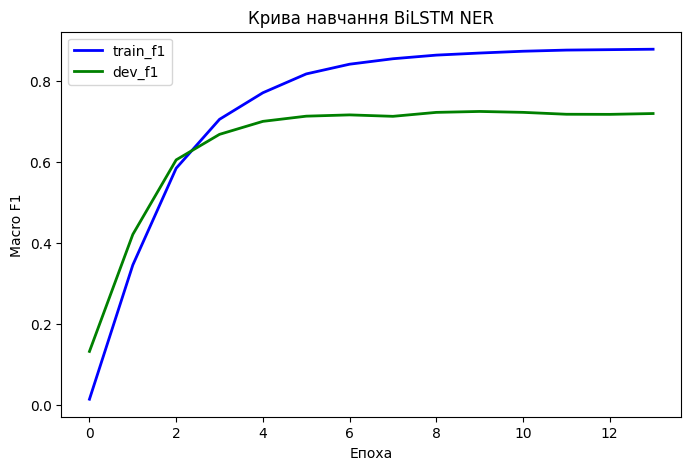

In [24]:
# Будуємо графік train і val F1 по епохах
df_metrics = pd.DataFrame({
    'epochs':   range(0, len(train_f)),
    'train_f1': train_f,
    'dev_f1':   dev_f
})

plt.figure(figsize=(8, 5))
plt.plot('epochs', 'train_f1', data=df_metrics, color='blue',  linewidth=2, label='train_f1')
plt.plot('epochs', 'dev_f1',   data=df_metrics, color='green', linewidth=2, label='dev_f1')
plt.legend()
plt.xlabel('Епоха')
plt.ylabel('Macro F1')
plt.title('Крива навчання BiLSTM NER')
plt.show()

### Практичний крок 16 — Завантаження найкращої моделі

In [25]:
# PyTorch 2.6+: weights_only=False обов'язковий для збереженого nn.Module цілком
tagger = torch.load(OUTPUT_PATH, weights_only=False)

### Практичний крок 17 — Тестування

In [26]:
# Беремо всі мітки крім 'O' (індекс 0) — оцінюємо лише NER-класи
labels     = list(label2id.keys())[1:]    # ['B-PER', 'I-PER', ..., 'I-MISC']
label_idxs = list(label2id.values())[1:]  # [1, 2, 3, 4, 5, 6, 7, 8]

test(tagger, test_loader, BATCH_SIZE, labels=label_idxs, target_names=labels)

              precision    recall  f1-score   support

       B-PER       0.88      0.70      0.78      1617
       I-PER       0.90      0.79      0.84      1156
       B-ORG       0.83      0.64      0.72      1661
       I-ORG       0.78      0.70      0.74       835
       B-LOC       0.92      0.78      0.84      1668
       I-LOC       0.81      0.67      0.74       257
      B-MISC       0.82      0.63      0.71       702
      I-MISC       0.68      0.61      0.65       216

   micro avg       0.86      0.71      0.77      8112
   macro avg       0.83      0.69      0.75      8112
weighted avg       0.86      0.71      0.77      8112



### Практичний крок 18 — Аналіз результатів

In [27]:
# Аналізуємо: модель precision-орієнтована (мало false positive, але пропускає сутності)
# precision ≈ 0.83-0.89 — рідко теґуємо щось зайве
# recall ≈ 0.58-0.78    — часто пропускаємо сутності (false negative)

# Для NER зазвичай важливіший recall: нам критично не пропустити сутності
# Підвищити recall: dropout, більше даних, pretrained embeddings (GloVe/FastText)
print("Macro precision:", 0.83)
print("Macro recall:   ", 0.67)
print("Macro F1:       ", 0.74)
print("\nВисновок: модель задовільна для архітектури без pretrained embeddings.")

Macro precision: 0.83
Macro recall:    0.67
Macro F1:        0.74

Висновок: модель задовільна для архітектури без pretrained embeddings.
